## **Full QSAR Classification Workflow**

This notebook executes full QSAR worflow from curation to external validation, with automatic savings in the outputs directories

### Configuration


In [1]:
target = 'pxr'  # 'ahr', 'pxr', 'car' The file names must be {target}_ligands.csv
model_name = 'xgb'  # 'rf', 'xgb', 'svm', 'lr', 'stacking'

In [ ]:
import os
from pathlib import Path
import sys

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

# Add parent directory to sys.path for imports
sys.path.append(str(BASE_DIR))

# Create output directories
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/plots", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_clf/{target}/reports", exist_ok=True)

### Curation

In [3]:
import pandas as pd
from utils_clf.curation import curate_data

# Load data
df = pd.read_csv(f"{BASE_DIR}/ligands/{target}/{target}_ligands.csv")

# Curate data
df_curated = curate_data(df,"SMILES", "Agonist_Activity")
display(df_curated.head())

Curation completed: 6258 valid molecules (out of 6260 initial).


,Agonist_Activity,SMILES
0,inactive,BrC(Br)Br
1,inactive,BrC(Br)C(Br)(Br)Br
2,inactive,BrC(Br)C(Br)Br
3,inactive,BrC/C=C/CBr
4,active,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br


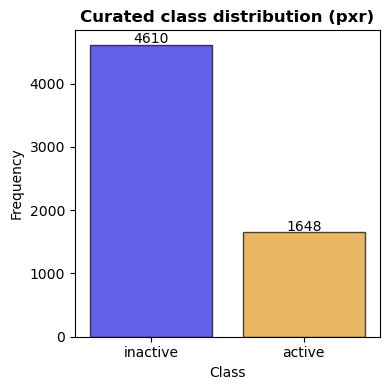

In [ ]:
from utils_clf.class_distribution import plot_dist

# Plot curated class distribution
plot = plot_dist(df_curated, "Agonist_Activity", target)

# Save figure
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/{target}_class_dist.png", dpi=300)

### Descriptors


In [5]:
from utils_clf.descriptors import descriptor_matrix

# Generate X and y
X, y = descriptor_matrix(df_curated, "SMILES", "Agonist_Activity")

# Full descriptor list for saving model components
full_descriptor_list = X.columns.tolist()

print(f"Descriptor matrix shape: {X.shape}")

Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 6258/6258 [02:05<00:00, 49.77it/s] 


Descriptor matrix shape: (6230, 217)


### Data split and encoding

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 4361 | Test: 1869


In [7]:
y_train_enc = y_train.map({"inactive": 0, "active": 1})
y_test_enc = y_test.map({"inactive": 0, "active": 1})

count_train = pd.Series(y_train_enc).value_counts()
count_test = pd.Series(y_test_enc).value_counts()

print(f"Train distribution: Active(1) = {count_train[1]}, Inactive(0) = {count_train[0]}")
print(f"Test distribution: Active(1) = {count_test[1]}, Inactive(0) = {count_test[0]}")

Train distribution: Active(1) = 1144, Inactive(0) = 3217
Test distribution: Active(1) = 490, Inactive(0) = 1379


### Feature filtering


In [8]:
from utils_clf.filtering import filter_features

X_train_filtered, X_test_filtered = filter_features(X_train, X_test)

Variance Filter (threshold 0.01)
Deleted features by variance: 24
Features after variance: 193

Correlation Filter (threshold 0.9)
Deleted features by correlation: 43
Final features post-filtering: 150


### Preprocessing & Genetic Algorithm

Preprocessing is fitted on all post-filtering features **before** the GA runs, so that the GA's internal cross-validation evaluates fitness on correctly scaled data (important for LR and SVM).  
Pipeline: `filter → scale (fit on 150 features) → GA (on scaled data) → subset to selected features`

In [ ]:
from utils_clf.preprocessor import build_preprocessor
from utils_clf.robust_ga import ga_feature_selection
from utils_clf.config import RANDOM_STATE, GA_N_GEN, GA_POP_SIZE

# --- Step 1: Preprocessing on ALL filtered features ---
preprocessor = build_preprocessor()
filtered_features = X_train_filtered.columns.tolist()

X_train_scaled = preprocessor.fit_transform(X_train_filtered)
X_test_scaled  = preprocessor.transform(X_test_filtered)

print(f"Preprocessor fitted on {len(filtered_features)} features")

# --- Step 2: Genetic Algorithm on pre-scaled data ---
selected_features, best_fitness, hof, log = ga_feature_selection(
    X_train_scaled, y_train_enc, filtered_features,
    n_gen=GA_N_GEN, pop_size=GA_POP_SIZE, random_state=RANDOM_STATE
)

# --- Step 3: Subset scaled matrices to GA-selected features ---
selected_indices = [filtered_features.index(f) for f in selected_features]
X_train_proc = X_train_scaled[:, selected_indices]
X_test_proc  = X_test_scaled[:, selected_indices]

print(f"\nX_train_proc shape: {X_train_proc.shape}")
print(f"X_test_proc shape:  {X_test_proc.shape}")

# --- Save selected features ---
selected_features_df = pd.DataFrame(selected_features, columns=["Selected_Features"])
selected_features_df.to_csv(
    f"{BASE_DIR}/outputs_clf/{target}/reports/selected_features.csv", index=False
)

### Training with optimization

In [ ]:
from utils_clf.optimization import optimize_model, save_model
from utils_clf.optimization import train_stacking_model

if model_name == "stacking":
    final_model = train_stacking_model(X_train_proc, y_train_enc)
    save_model(BASE_DIR, target, model_name, final_model,
               full_descriptor_list, filtered_features, selected_features, preprocessor)

else:
    final_model = optimize_model(X_train_proc, y_train_enc, model_name)
    save_model(BASE_DIR, target, model_name, final_model,
               full_descriptor_list, filtered_features, selected_features, preprocessor)

### Internal validation

  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0   xgb    pxr        0.5  0.844837       0.82578   0.675439  0.785714   

   Specificity  F1_score   ROC_AUC    PR_AUC       MCC  
0     0.865845  0.726415  0.900114  0.746263  0.622432  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


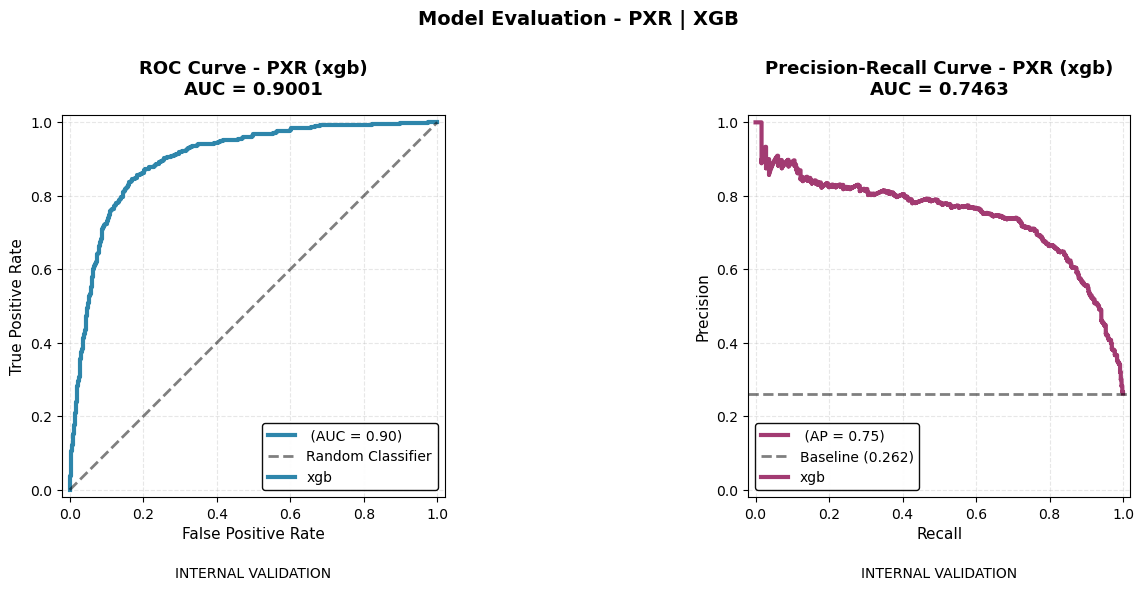

C:\Users\elias\AppData\Local\Temp\ipykernel_18180\2441150845.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


In [ ]:
from utils_clf.validation import compute_metrics
plot, metrics = compute_metrics(final_model, X_test_proc, y_test_enc, model_name, target)
plot.show()

#Save metrics and plot
metrics['metrics_df'].to_csv(f"{BASE_DIR}/outputs_clf/{target}/reports/internal_validation_{target}_{model_name}.csv", index=False)
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/internal_roc_pr_{target}_{model_name}.png", dpi=300)

### Applicability Domain (AD)


Training set size: 4361
Number of descriptors: 42
AD threshold (h*): 0.0296
Compounds outside AD: 3.5% (65/1869)
Leverage range - Train: [0.0012, 0.4122]
Leverage range - Test:  [0.0013, 0.2983]


C:\Users\elias\AppData\Local\Temp\ipykernel_18180\760455249.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


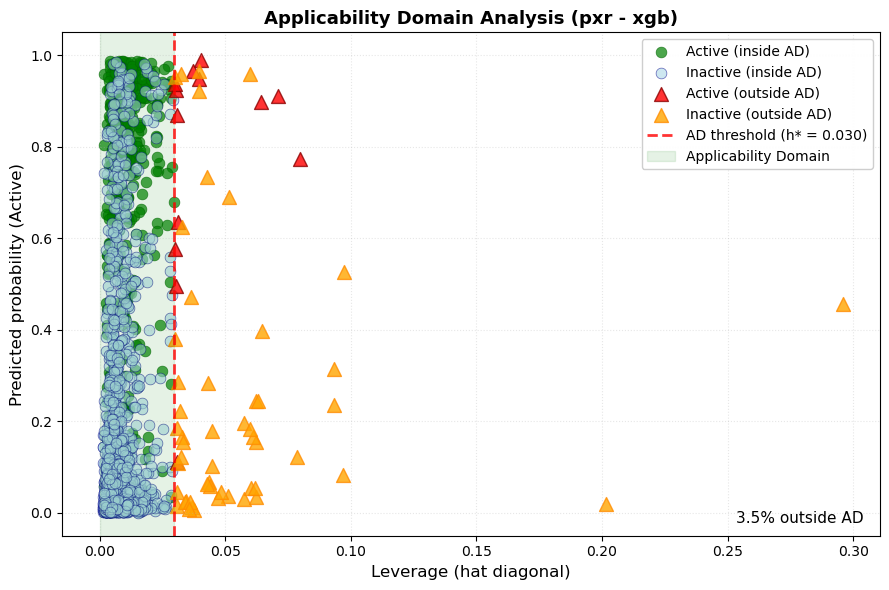

In [ ]:
from utils_clf.applicability_domain import applicability_domain_analysis as ad
y_proba = metrics["y_proba"]
plot = ad(target, model_name, X_train_proc, X_test_proc, y_test_enc, y_proba)
plot.show()
# Save plot
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_{target}_{model_name}.png", dpi=300, bbox_inches="tight")

### External Validation

Curation completed: 306 valid molecules (out of 306 initial).
Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 306/306 [00:05<00:00, 60.96it/s]


  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0   xgb    pxr        0.5  0.864486       0.87709   0.770492  0.989474   

   Specificity  F1_score   ROC_AUC    PR_AUC       MCC  
0     0.764706  0.866359  0.958249  0.942593  0.756896  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


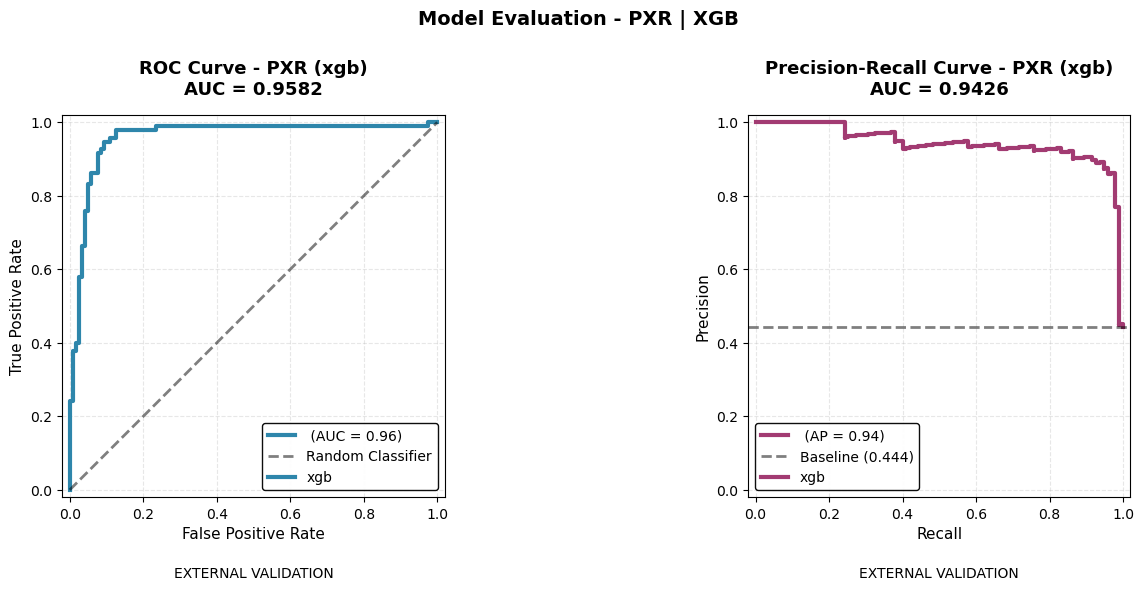

In [19]:
# Load external dataset
df_ext = pd.read_csv(f"{BASE_DIR}/ext_ligands/{target}/ext_{target}_ligands.csv")
# Curation
df_ext_curated = curate_data(df_ext,"SMILES", "Agonist_Activity")
# Descriptor calculation
X_ext, y_ext = descriptor_matrix(df_ext_curated, "SMILES", "Agonist_Activity")
# Split and encode labels
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext,
    stratify=y_ext,
    test_size=0.3,
    random_state=42
)
y_ext_train_enc = y_ext_train.map({"inactive": 0, "active": 1})
# Apply selected features to train set
X_ext_filtered = X_ext_train[selected_features]
# Preprocess
X_ext_proc = preprocessor.transform(X_ext_filtered)
# Evaluation
plot_ext, metrics_ext = compute_metrics(final_model, X_ext_proc, y_ext_train_enc, model_name, target, data_type="external")

# Save metrics and plot
metrics_ext['metrics_df'].to_csv(
    f"{BASE_DIR}/outputs_clf/{target}/reports/external_validation_{target}_{model_name}.csv", index=False)
plot_ext.savefig(
    f"{BASE_DIR}/outputs_clf/{target}/plots/external_roc_pr_{target}_{model_name}.png", dpi=300)

Training set size: 4361
Number of descriptors: 42
AD threshold (h*): 0.0296
Compounds outside AD: 7.9% (17/214)
Leverage range - Train: [0.0012, 0.4122]
Leverage range - Test:  [0.0021, 0.1078]


C:\Users\elias\AppData\Local\Temp\ipykernel_18180\2629806263.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ext_ad.show()


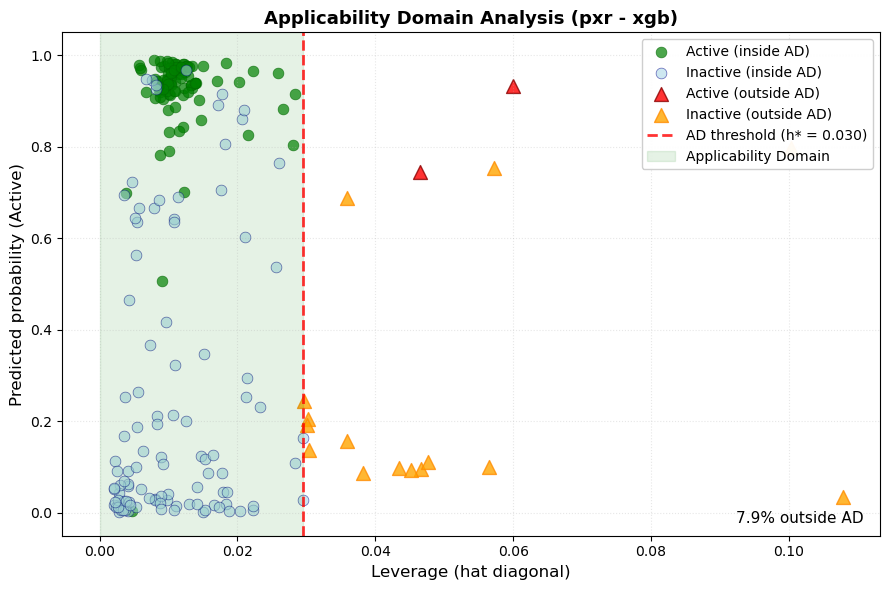

In [20]:
# Applicability domain analysis for external set
y_ext_proba = metrics_ext["y_proba"]
ext_ad = ad(target, model_name, X_train_proc, X_ext_proc, y_ext_train_enc, y_ext_proba)
ext_ad.show()

# Save plot
ext_ad.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_ext_{target}_{model_name}.png", dpi=300, bbox_inches="tight")